# EDA

## IMPORTAR PAQUETES

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [25]:
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_resultado_calidad.pkl')
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_resultado_calidad.pkl')

## EDA CATEGÓRICAS

### Análisis estadístico

No incluímos la variable 'd' ya que va a tener demasiados valores.

In [26]:
cat.columns.to_list()

['store_id',
 'item_id',
 'd',
 'year',
 'month',
 'wday',
 'weekday',
 'event_name_1',
 'event_type_1']

In [27]:
incluir = cat.columns.to_list()
del incluir[2]

In [28]:
def frecuencias_cat(df_cat):
    # Asegúrate de que todas las columnas son de tipo 'str' para evitar problemas de comparación
    df_cat = df_cat.astype(str)
    
    resultado = df_cat.apply(lambda x: x.value_counts(normalize=True)) \
                      .T.stack() \
                      .to_frame().reset_index() \
                      .rename(columns={'level_0': 'Variable', 'level_1': 'Valor', 0: "Frecuencia"}) \
                      .sort_values(by=['Variable', 'Frecuencia'])
    return resultado


In [29]:
pd.set_option('display.max_rows', None)

frecuencias_cat(cat[incluir])

,Variable,Valor,Frecuencia
41,event_name_1,Chanukah End,0.002
42,event_name_1,Christmas,0.002
43,event_name_1,Cinco De Mayo,0.002
48,event_name_1,Father's day,0.002
61,event_name_1,OrthodoxEaster,0.002
44,event_name_1,ColumbusDay,0.003
45,event_name_1,Easter,0.003
46,event_name_1,Eid al-Fitr,0.003
47,event_name_1,EidAlAdha,0.003
49,event_name_1,Halloween,0.003


In [30]:
pd.set_option('display.max_rows', 6)

### Análisis gráfico

In [31]:
def graficos_eda_categoricos(cat):
    
    #Calculamos el número de filas que necesitamos
    from math import ceil
    filas = ceil(cat.shape[1] / 2)

    #Definimos el gráfico
    f, ax = plt.subplots(nrows = filas, ncols = 2, figsize = (16, filas * 6))

    #Aplanamos para iterar por el gráfico como si fuera de 1 dimensión en lugar de 2
    ax = ax.flat 

    #Creamos el bucle que va añadiendo gráficos
    for cada, variable in enumerate(cat):
        cat[variable].value_counts().plot.barh(ax = ax[cada])
        ax[cada].set_title(variable, fontsize = 12, fontweight = "bold")
        ax[cada].tick_params(labelsize = 12)

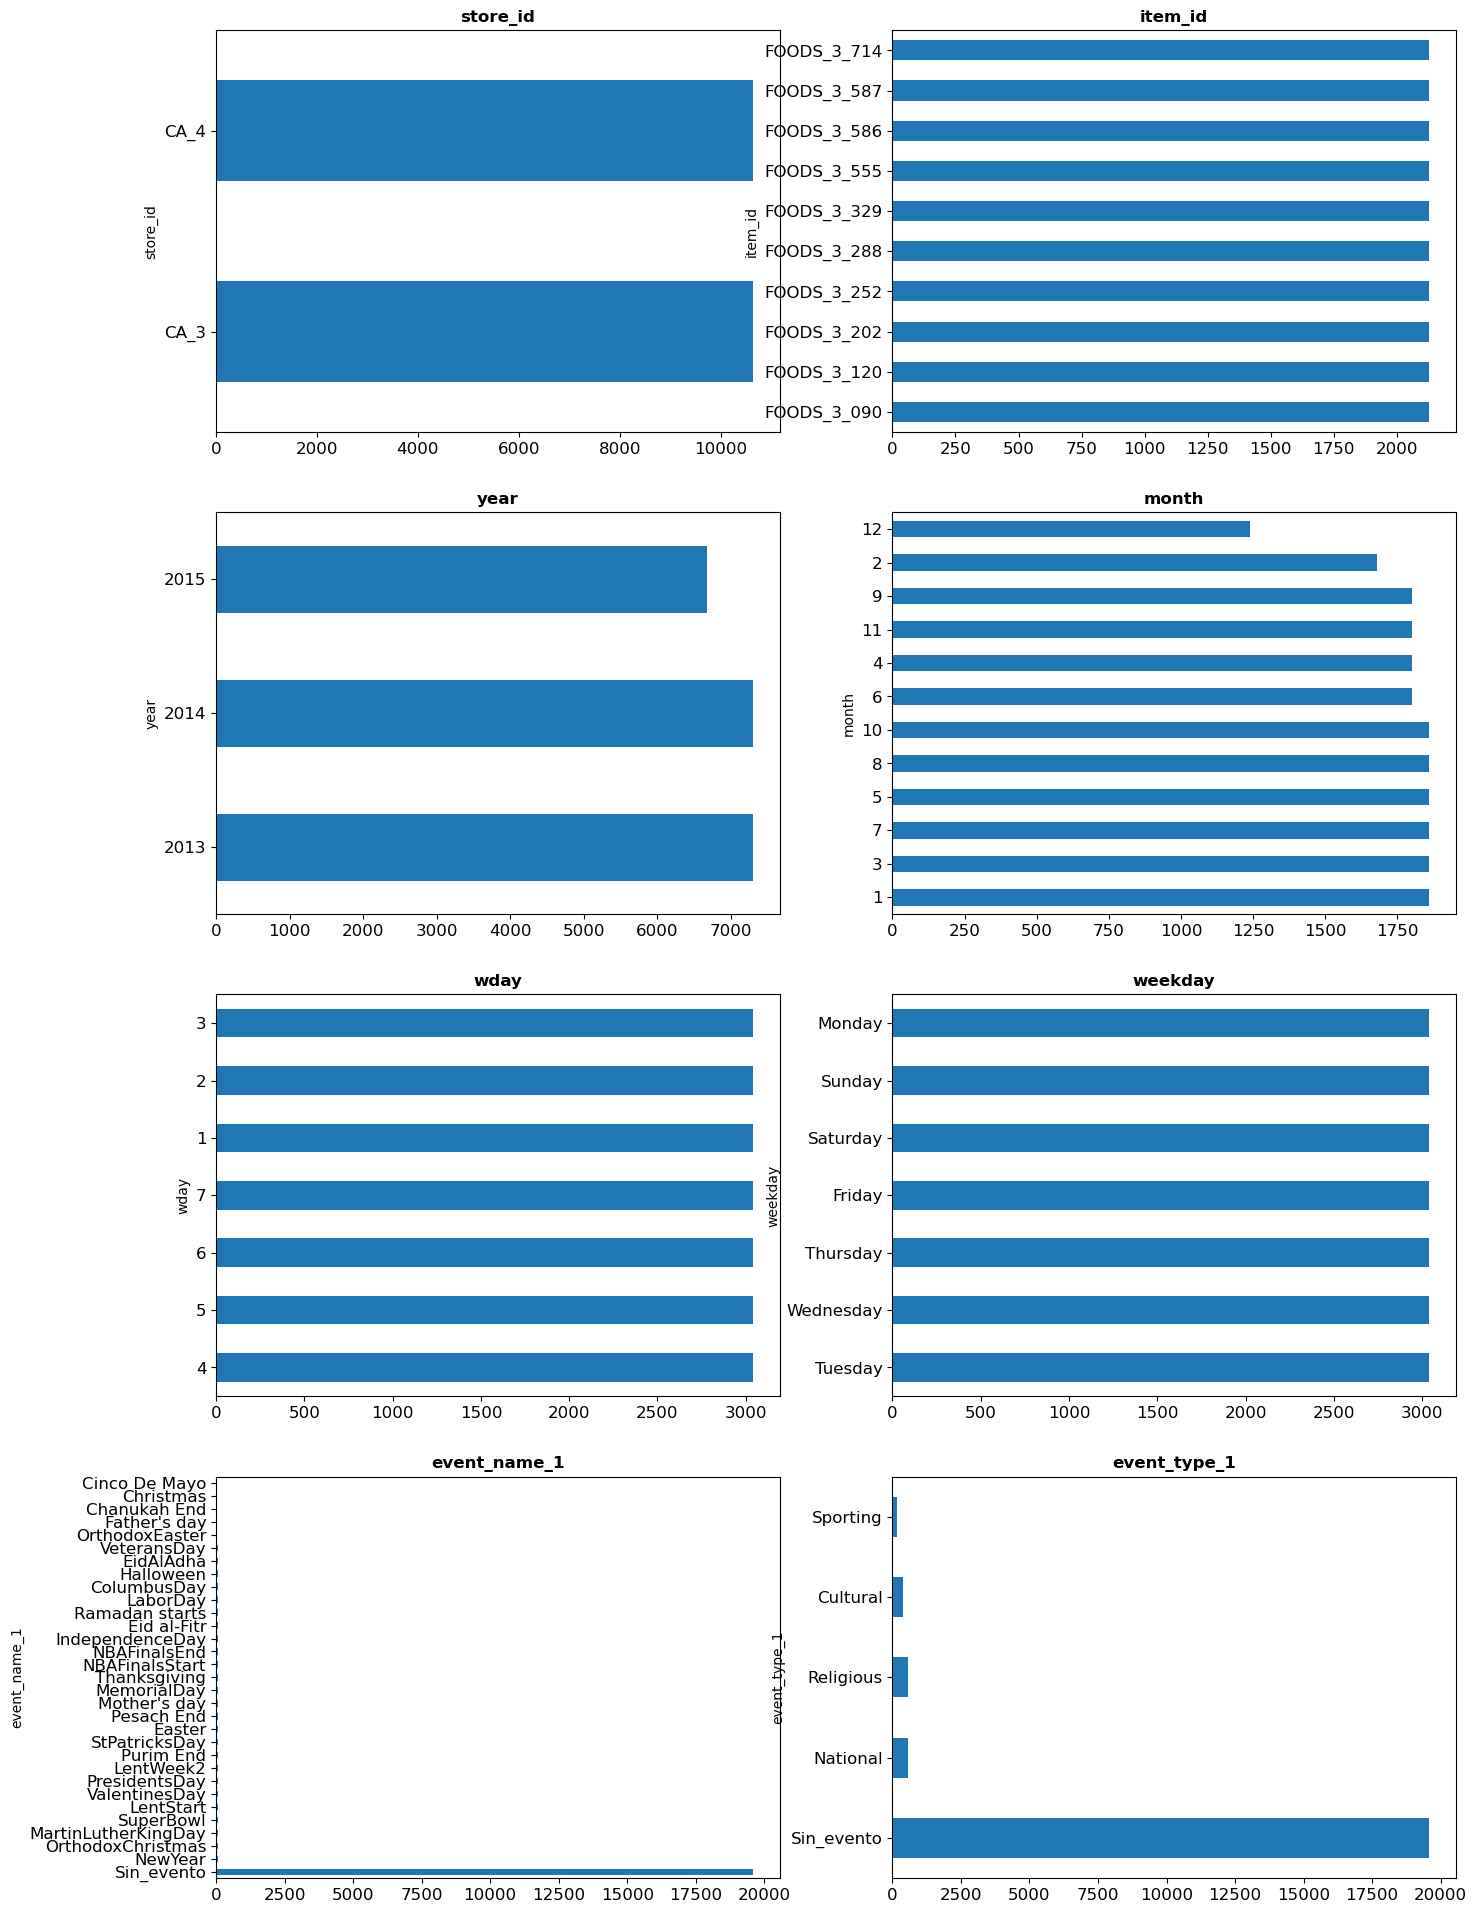

In [32]:
graficos_eda_categoricos(cat[incluir])

## EDA NUMÉRICAS

### Análisis estadístico

In [33]:
def estadisticos_cont(num):
    #Calculamos describe
    estadisticos = num.describe().T
    #Añadimos la mediana
    estadisticos['median'] = num.median()
    #Reordenamos para que la mediana esté al lado de la media
    estadisticos = estadisticos.iloc[:,[0,1,8,2,3,4,5,6,7]]
    #Lo devolvemos
    return(estadisticos)

In [34]:
estadisticos_cont(num)

,count,mean,median,std,min,25%,50%,75%,max
wm_yr_wk,21280.000,11415.023,11420.000,82.875,11249.000,11335.000,11420.000,11506.000,11544.000
ventas,21280.000,28.875,18.000,38.988,0.000,6.000,18.000,37.000,763.000
sell_price,21280.000,2.394,1.580,1.236,1.000,1.500,1.580,2.980,4.980


### Análisis gráfico

En este caso el análisis gráfico que tiene más sentido es el de ventas y precios por diferentes dimensiones.

Así que primero necesitamos volver a unir los dos dataframes.

In [35]:
df = pd.concat([cat,num], axis=1)

df.head()

,store_id,item_id,d,year,month,wday,weekday,event_name_1,event_type_1,wm_yr_wk,ventas,sell_price
date,,,,,,,,,,,,
2013-01-01,CA_3,FOODS_3_090,d_704,2013,1,4,Tuesday,NewYear,National,11249,0,1.250
2013-01-01,CA_3,FOODS_3_120,d_704,2013,1,4,Tuesday,NewYear,National,11249,33,1.250
2013-01-01,CA_3,FOODS_3_202,d_704,2013,1,4,Tuesday,NewYear,National,11249,0,4.980
2013-01-01,CA_3,FOODS_3_252,d_704,2013,1,4,Tuesday,NewYear,National,11249,0,4.980
2013-01-01,CA_3,FOODS_3_288,d_704,2013,1,4,Tuesday,NewYear,National,11249,20,4.280


#### Tendencia global de las ventas

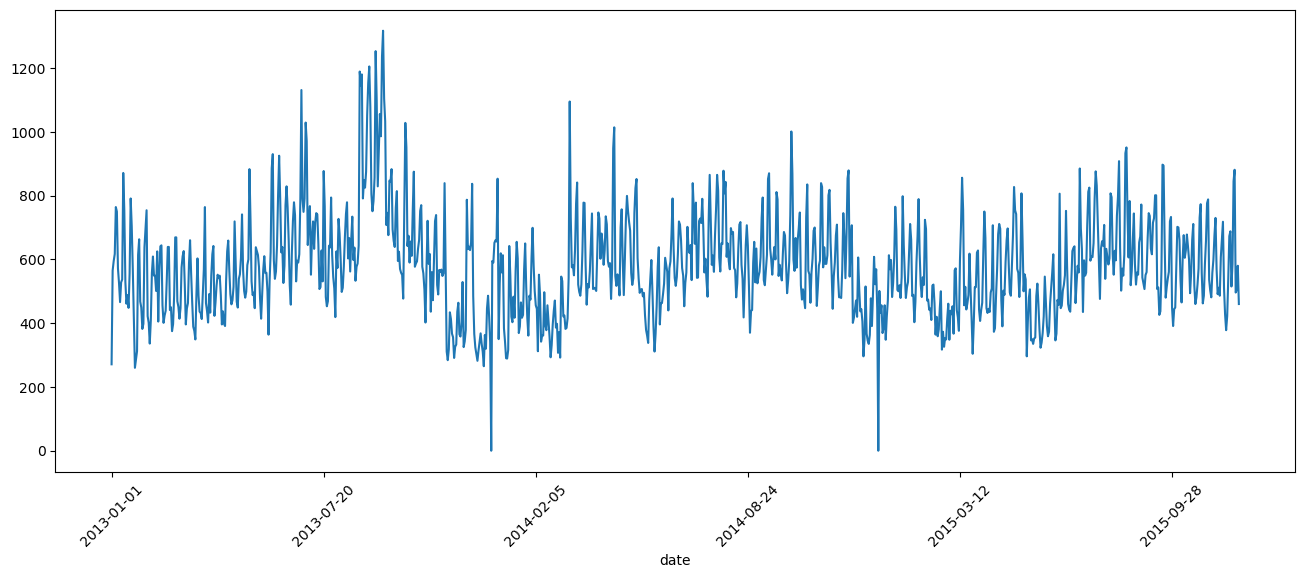

In [36]:
df.groupby('date').ventas.sum().plot(figsize=(16, 6), rot=45);

#### Tendencia de las ventas por producto

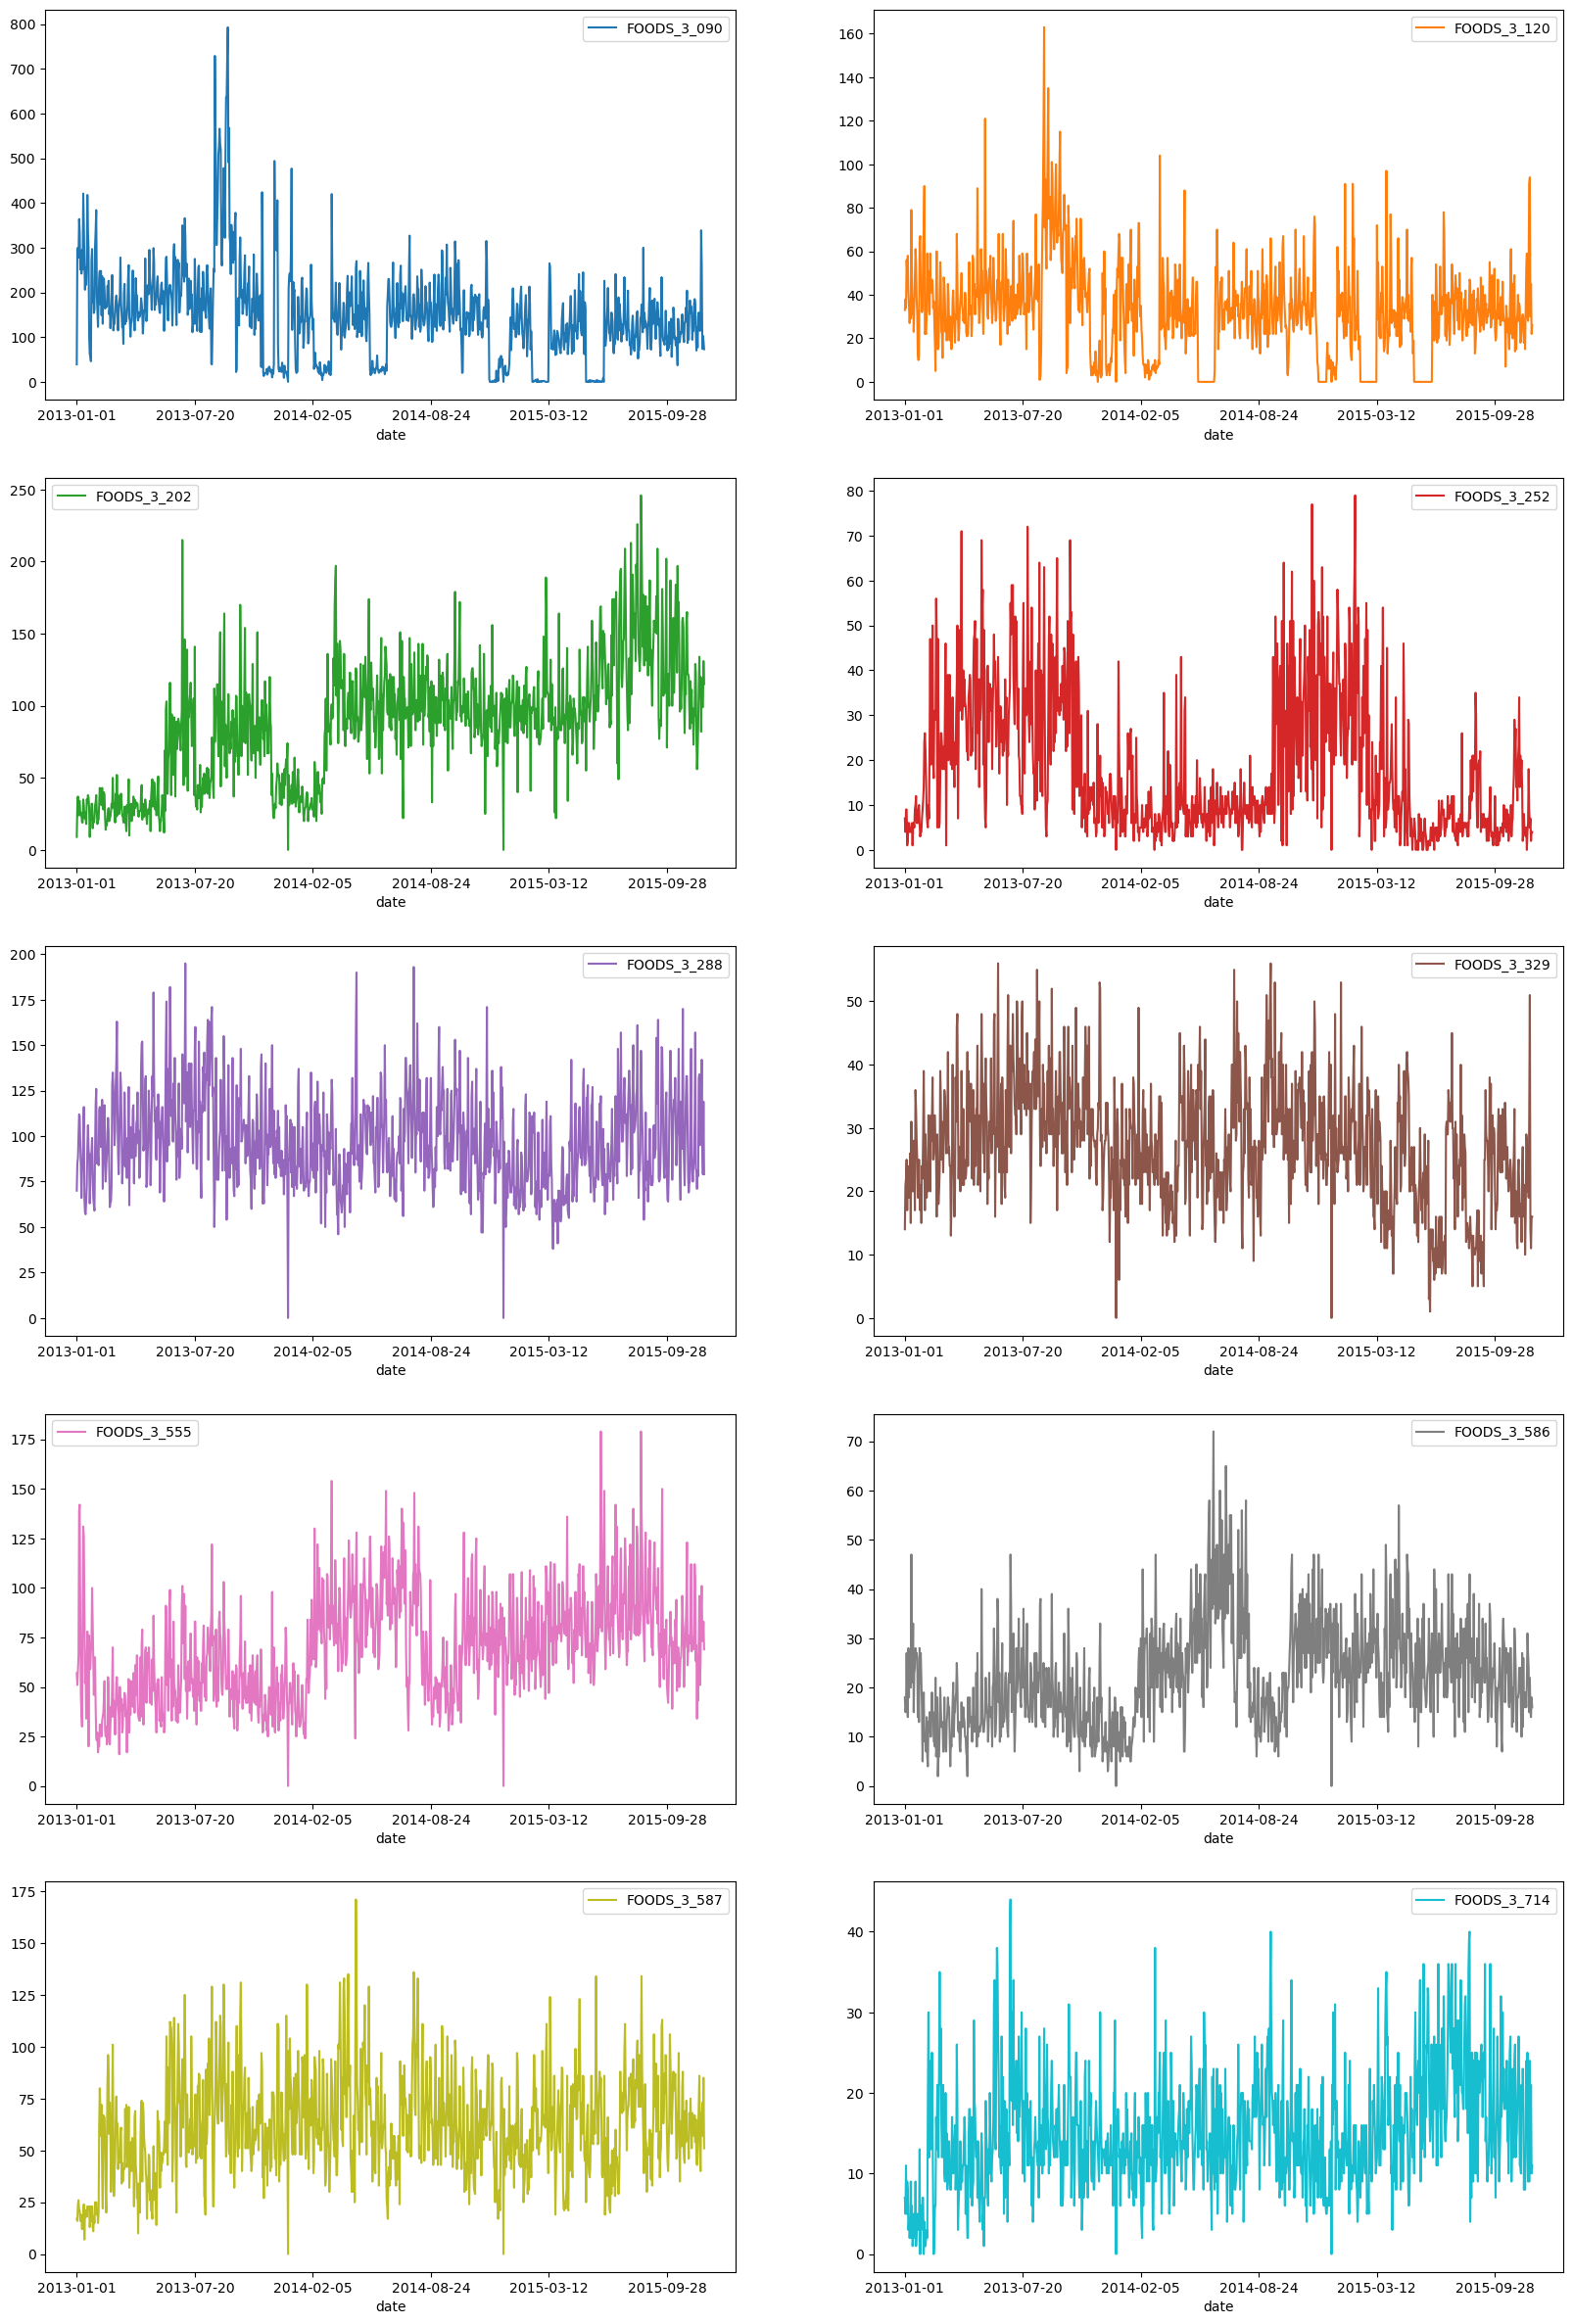

In [37]:
df.groupby(['date','item_id']).ventas.sum().unstack().plot(subplots = True,  layout = (5,2), sharex=False, figsize=(20,30));

#### Tendencia de las ventas por tienda y producto

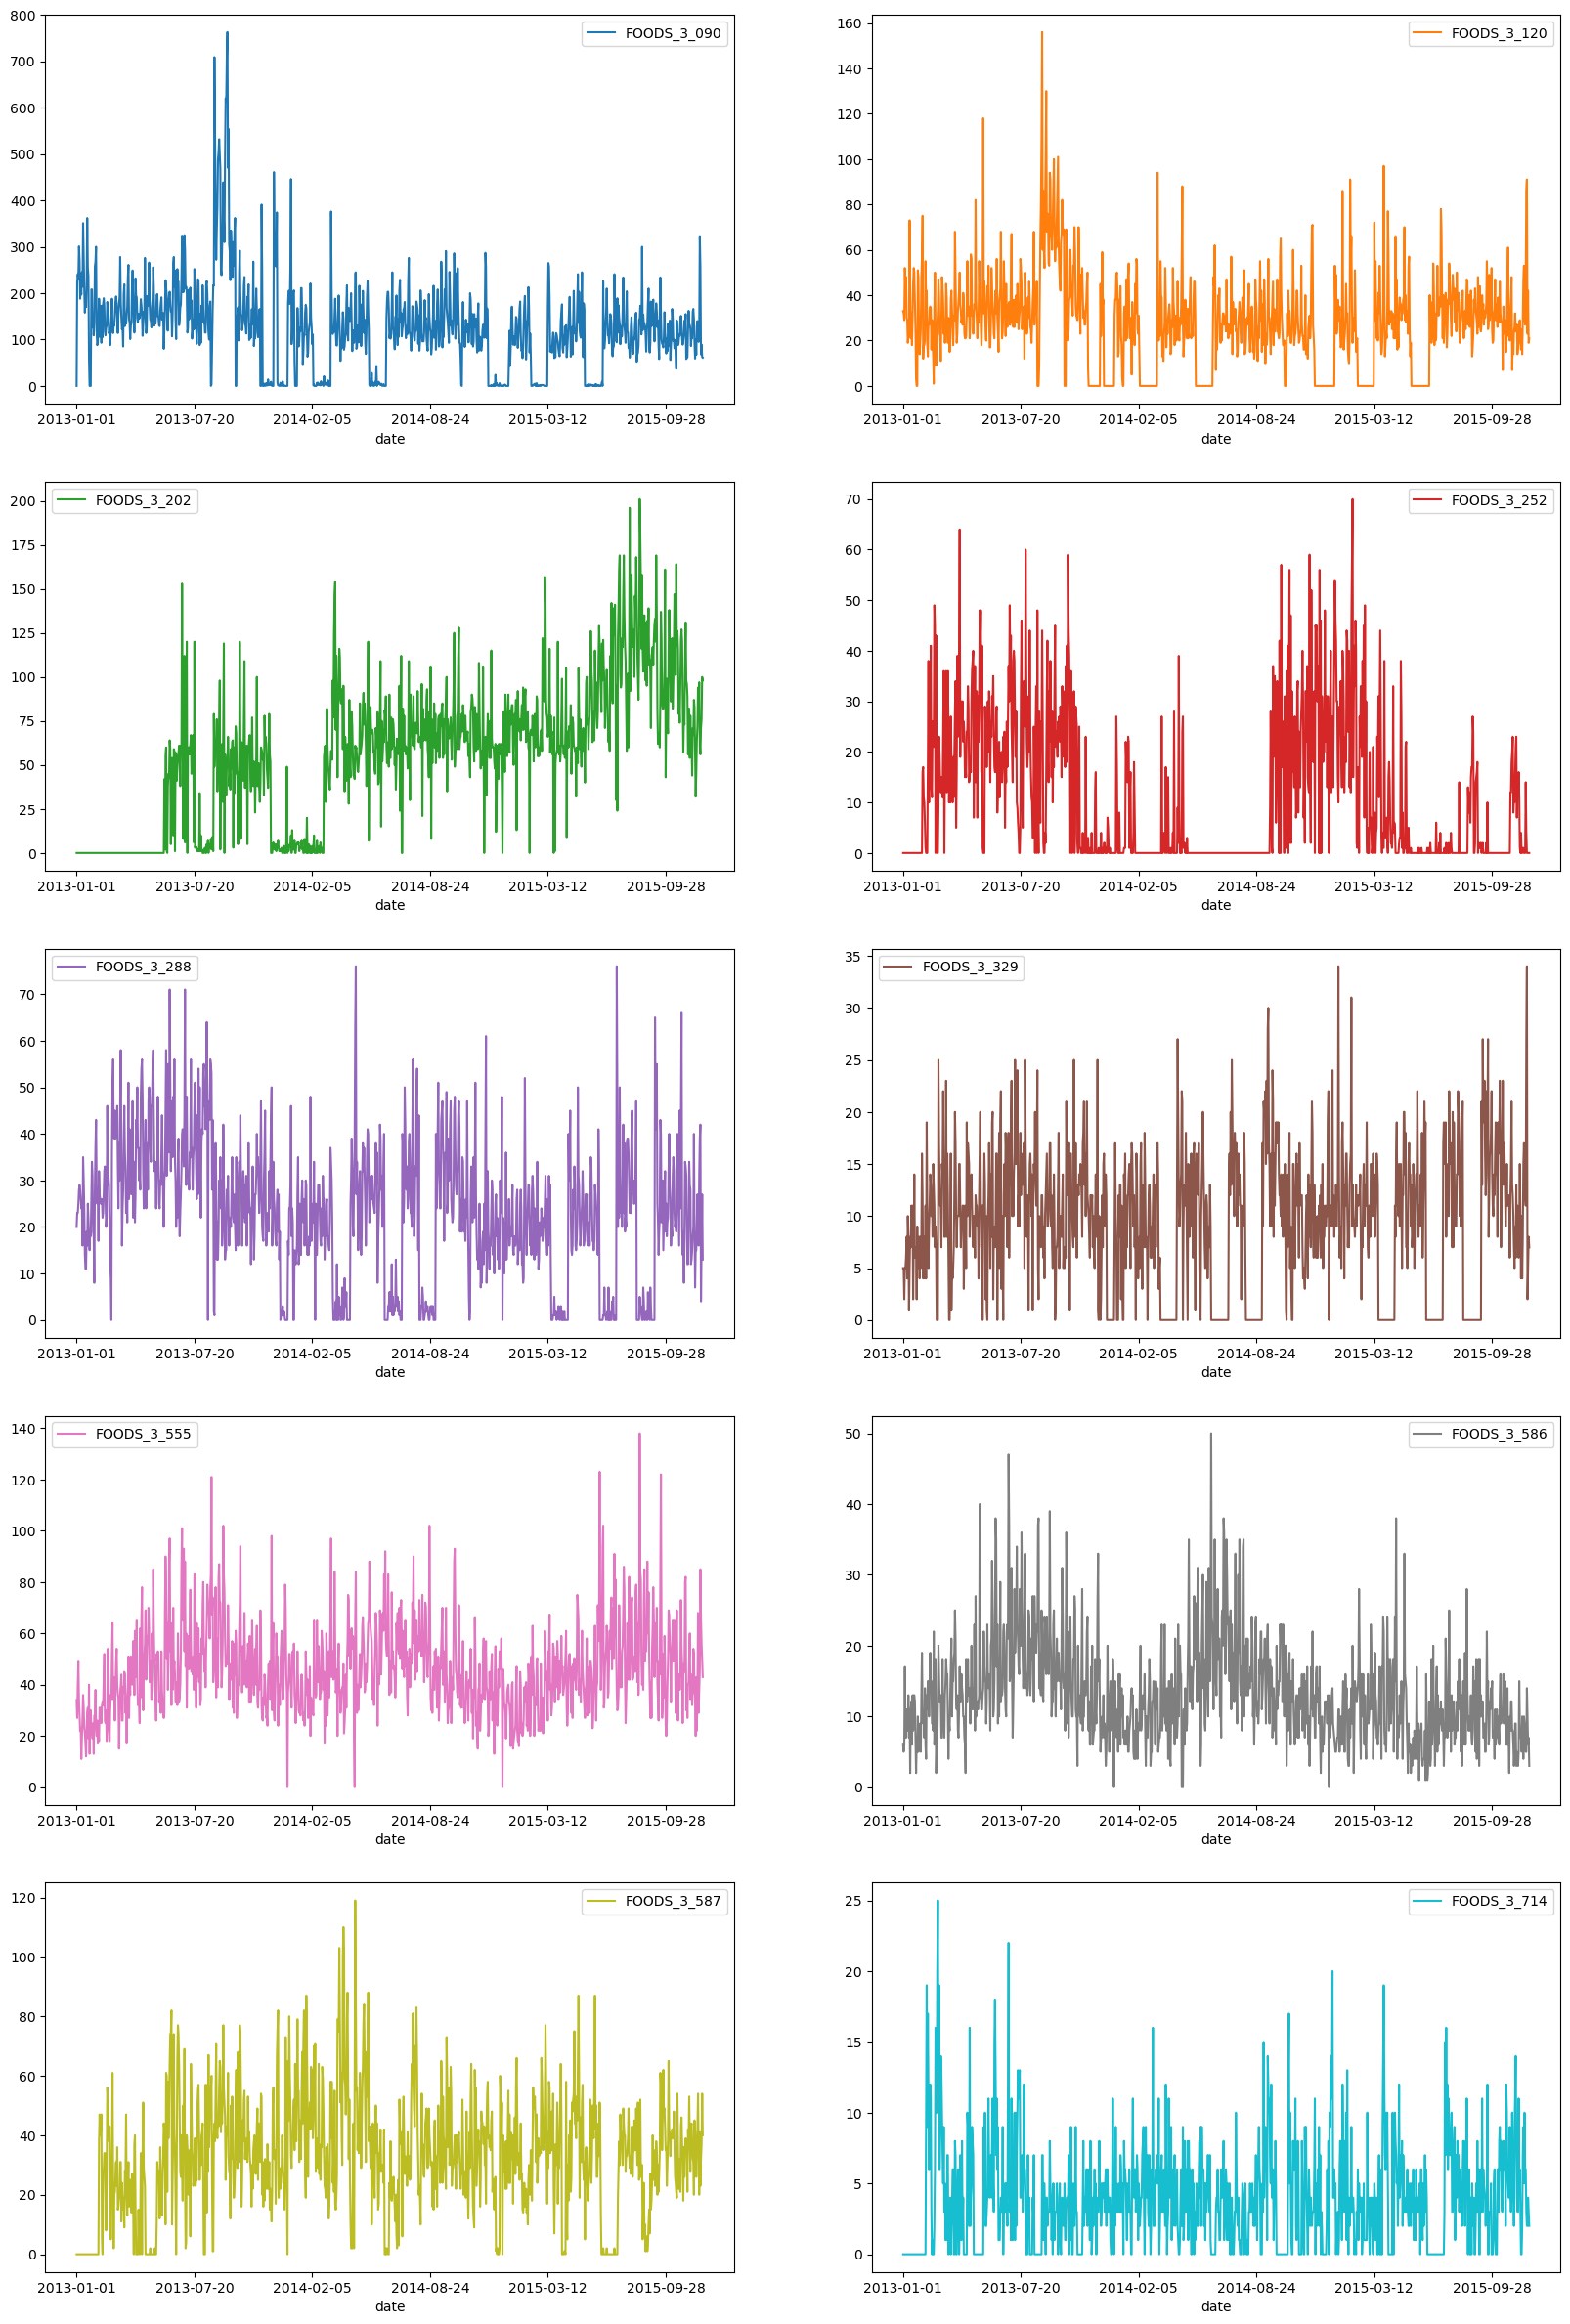

In [38]:
df.loc[df.store_id == 'CA_3'].groupby(['date','item_id']).ventas.sum().unstack().plot(subplots = True,  layout = (5,2), sharex=False, figsize=(20,30));

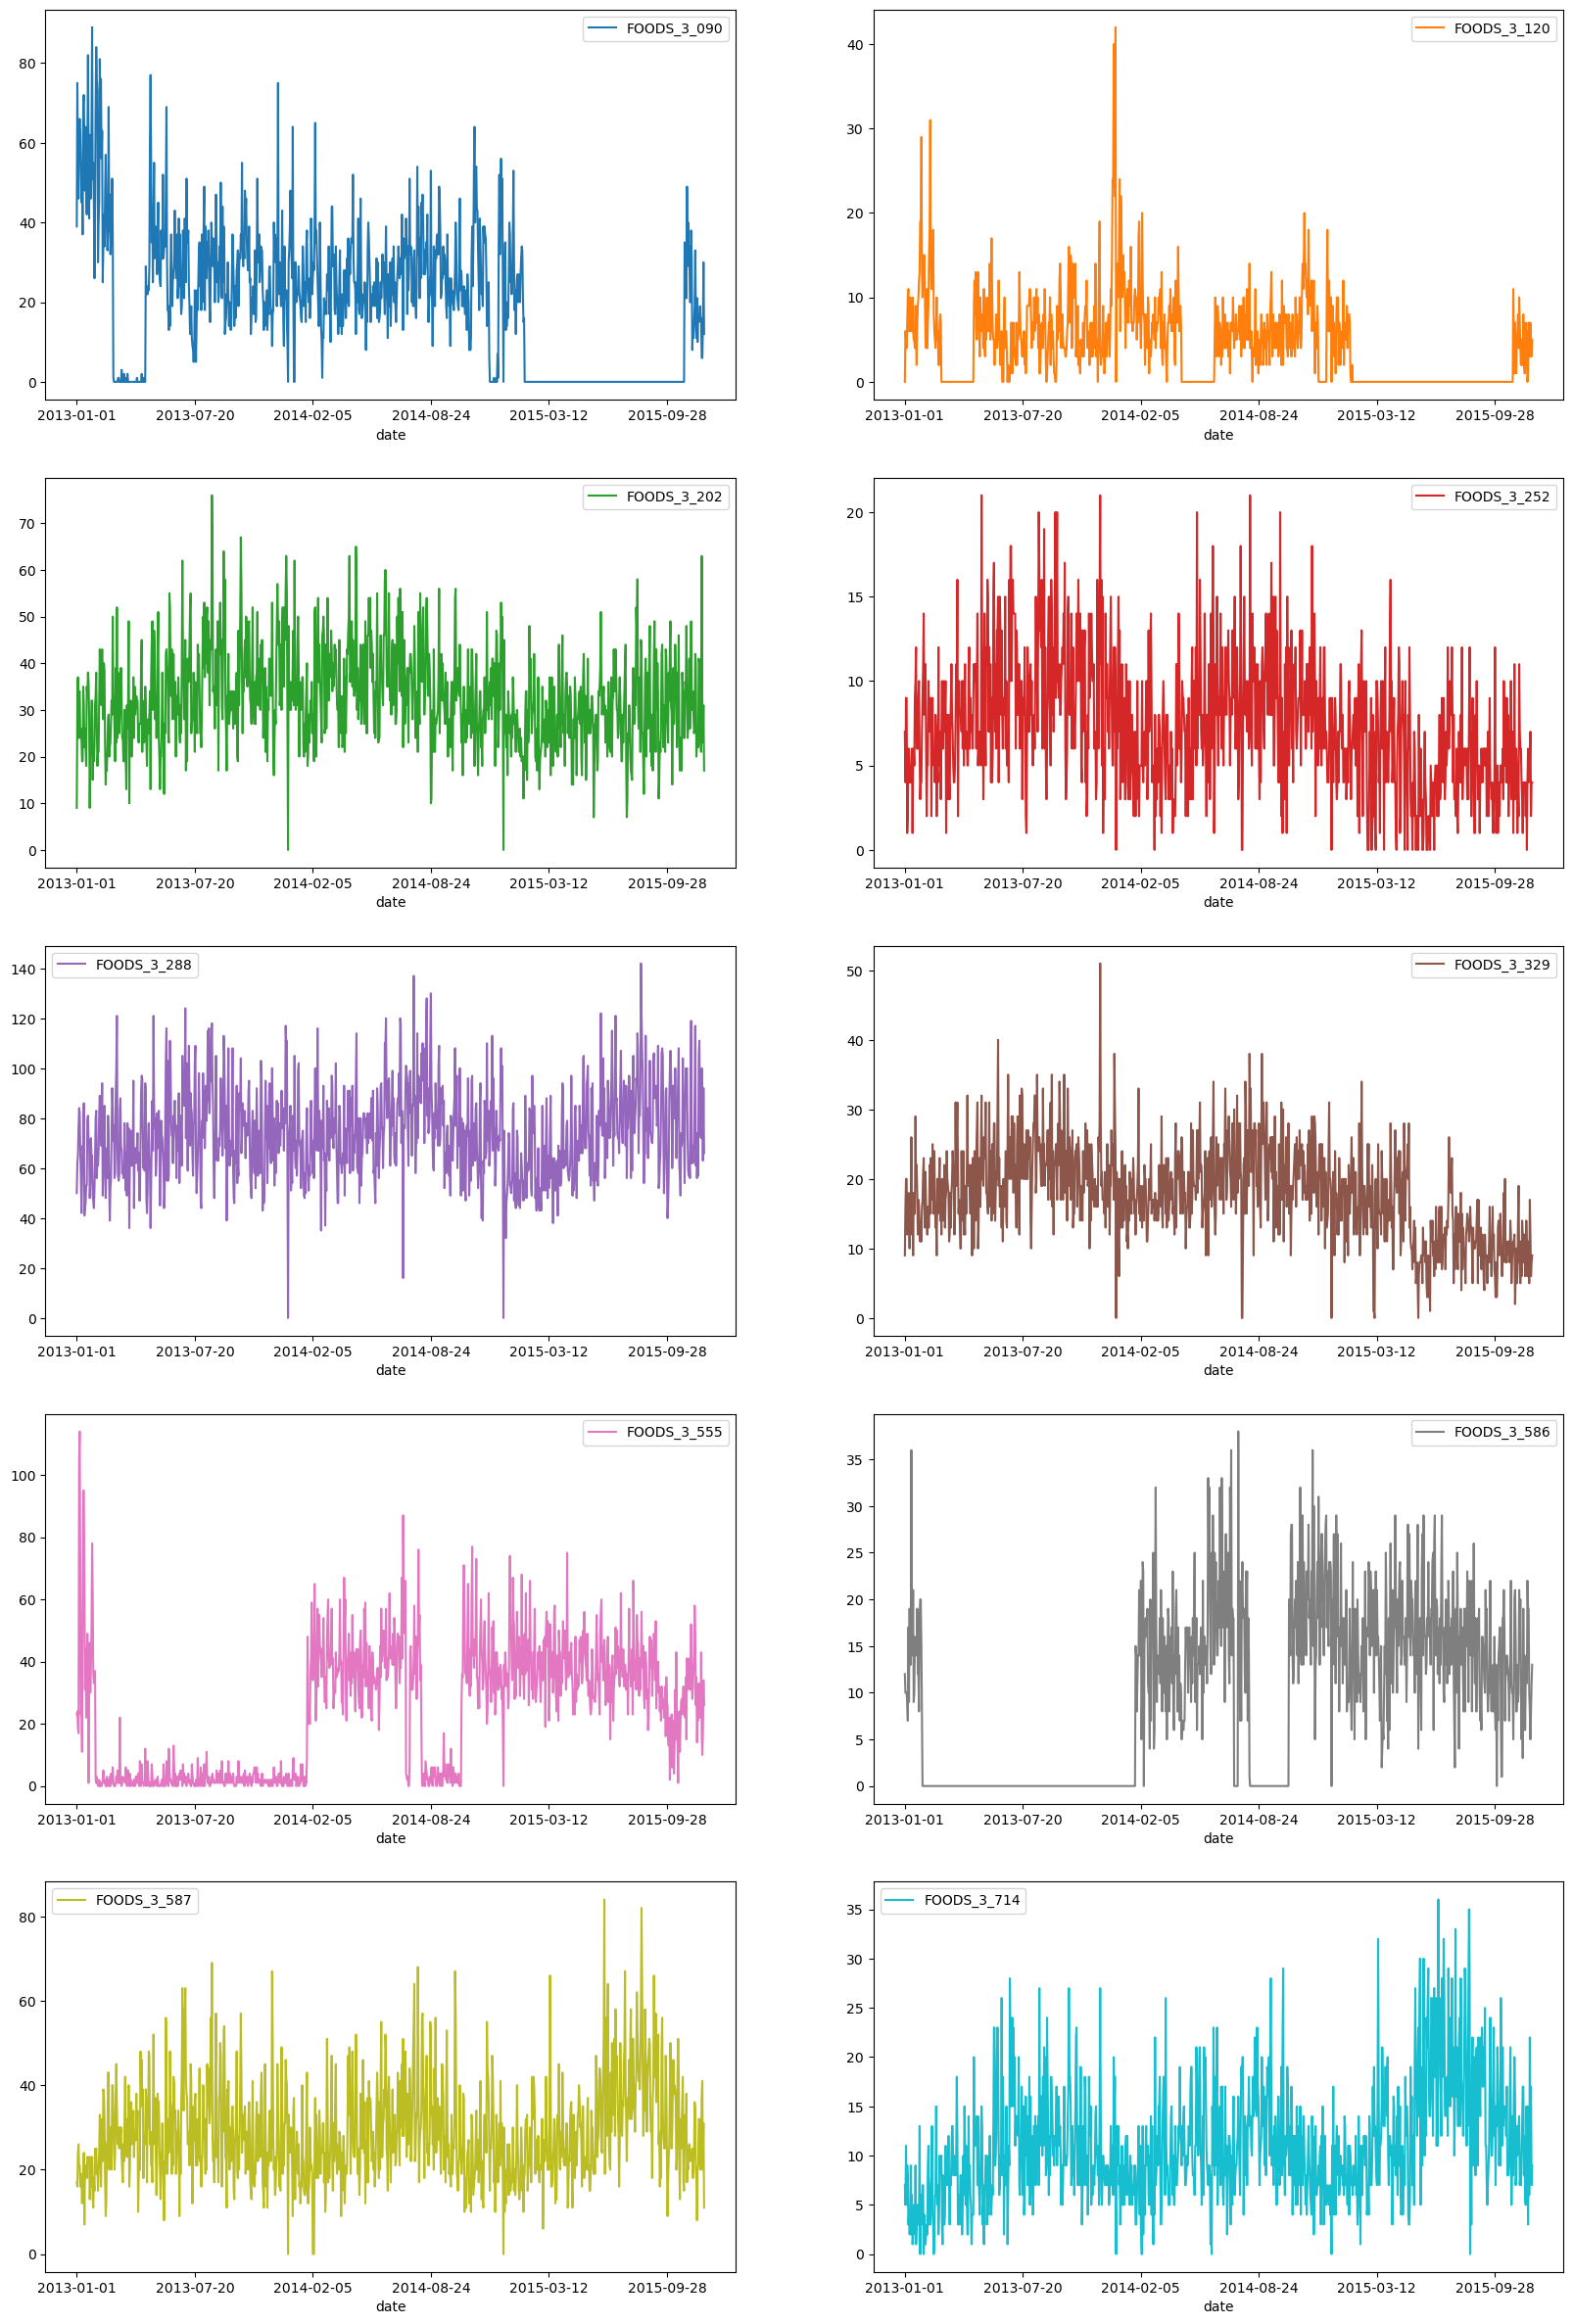

In [39]:
df.loc[df.store_id == 'CA_4'].groupby(['date','item_id']).ventas.sum().unstack().plot(subplots = True,  layout = (5,2), sharex=False, figsize=(20,30));

Conclusiones:

* Estructura jerárquica
* Hay productos nuevos a nivel de tienda
* Aunque no a nivel general, por lo que podríamos pensar que no son realmente productos nuevos si no demanda intermitente
* Hay demanda intermitente
    * No sabemos la causa: falta de demanda, retirada del mercado o rotura de stock

Acciones:

* Modelizar a nivel tienda producto
* Crear una variable que capture el efecto de la demanda intermitente
* Utilizar algoritmos basados en árboles y rápidos: lightGBM

#### Tendencia del precio por producto

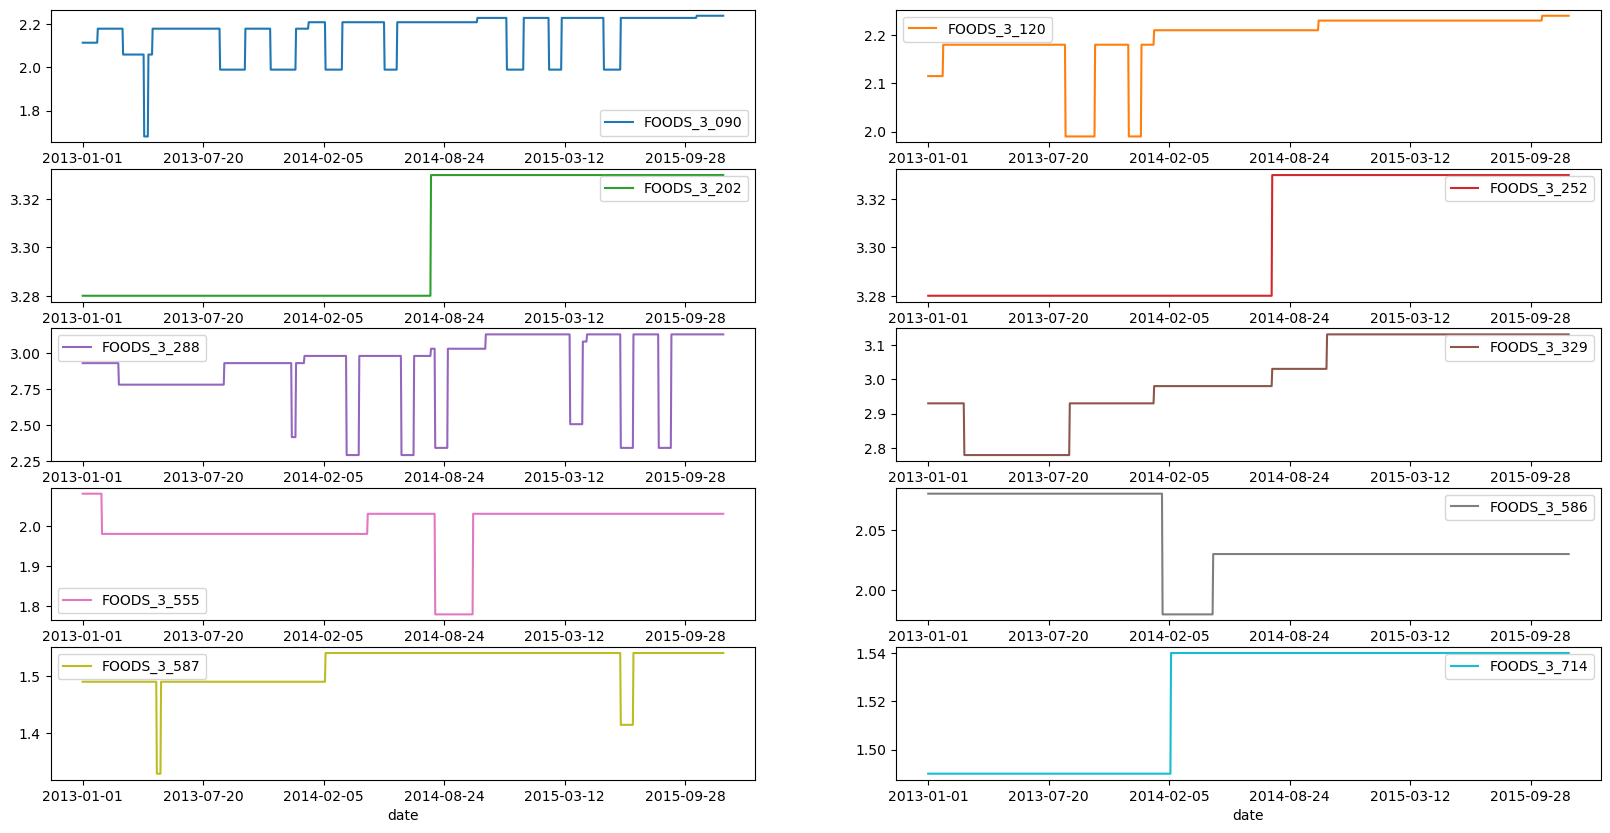

In [40]:
df.groupby(['date','item_id']).sell_price.mean().unstack().plot(subplots = True,  layout = (5,2), sharex=False, figsize=(20,10));

Conclusiones:

* Las políticas de precio varían mucho por producto
* Parece que las promociones son frecuentes
* Sería muy útil disponer de un calendario de promociones

#### Estacionalidad por producto

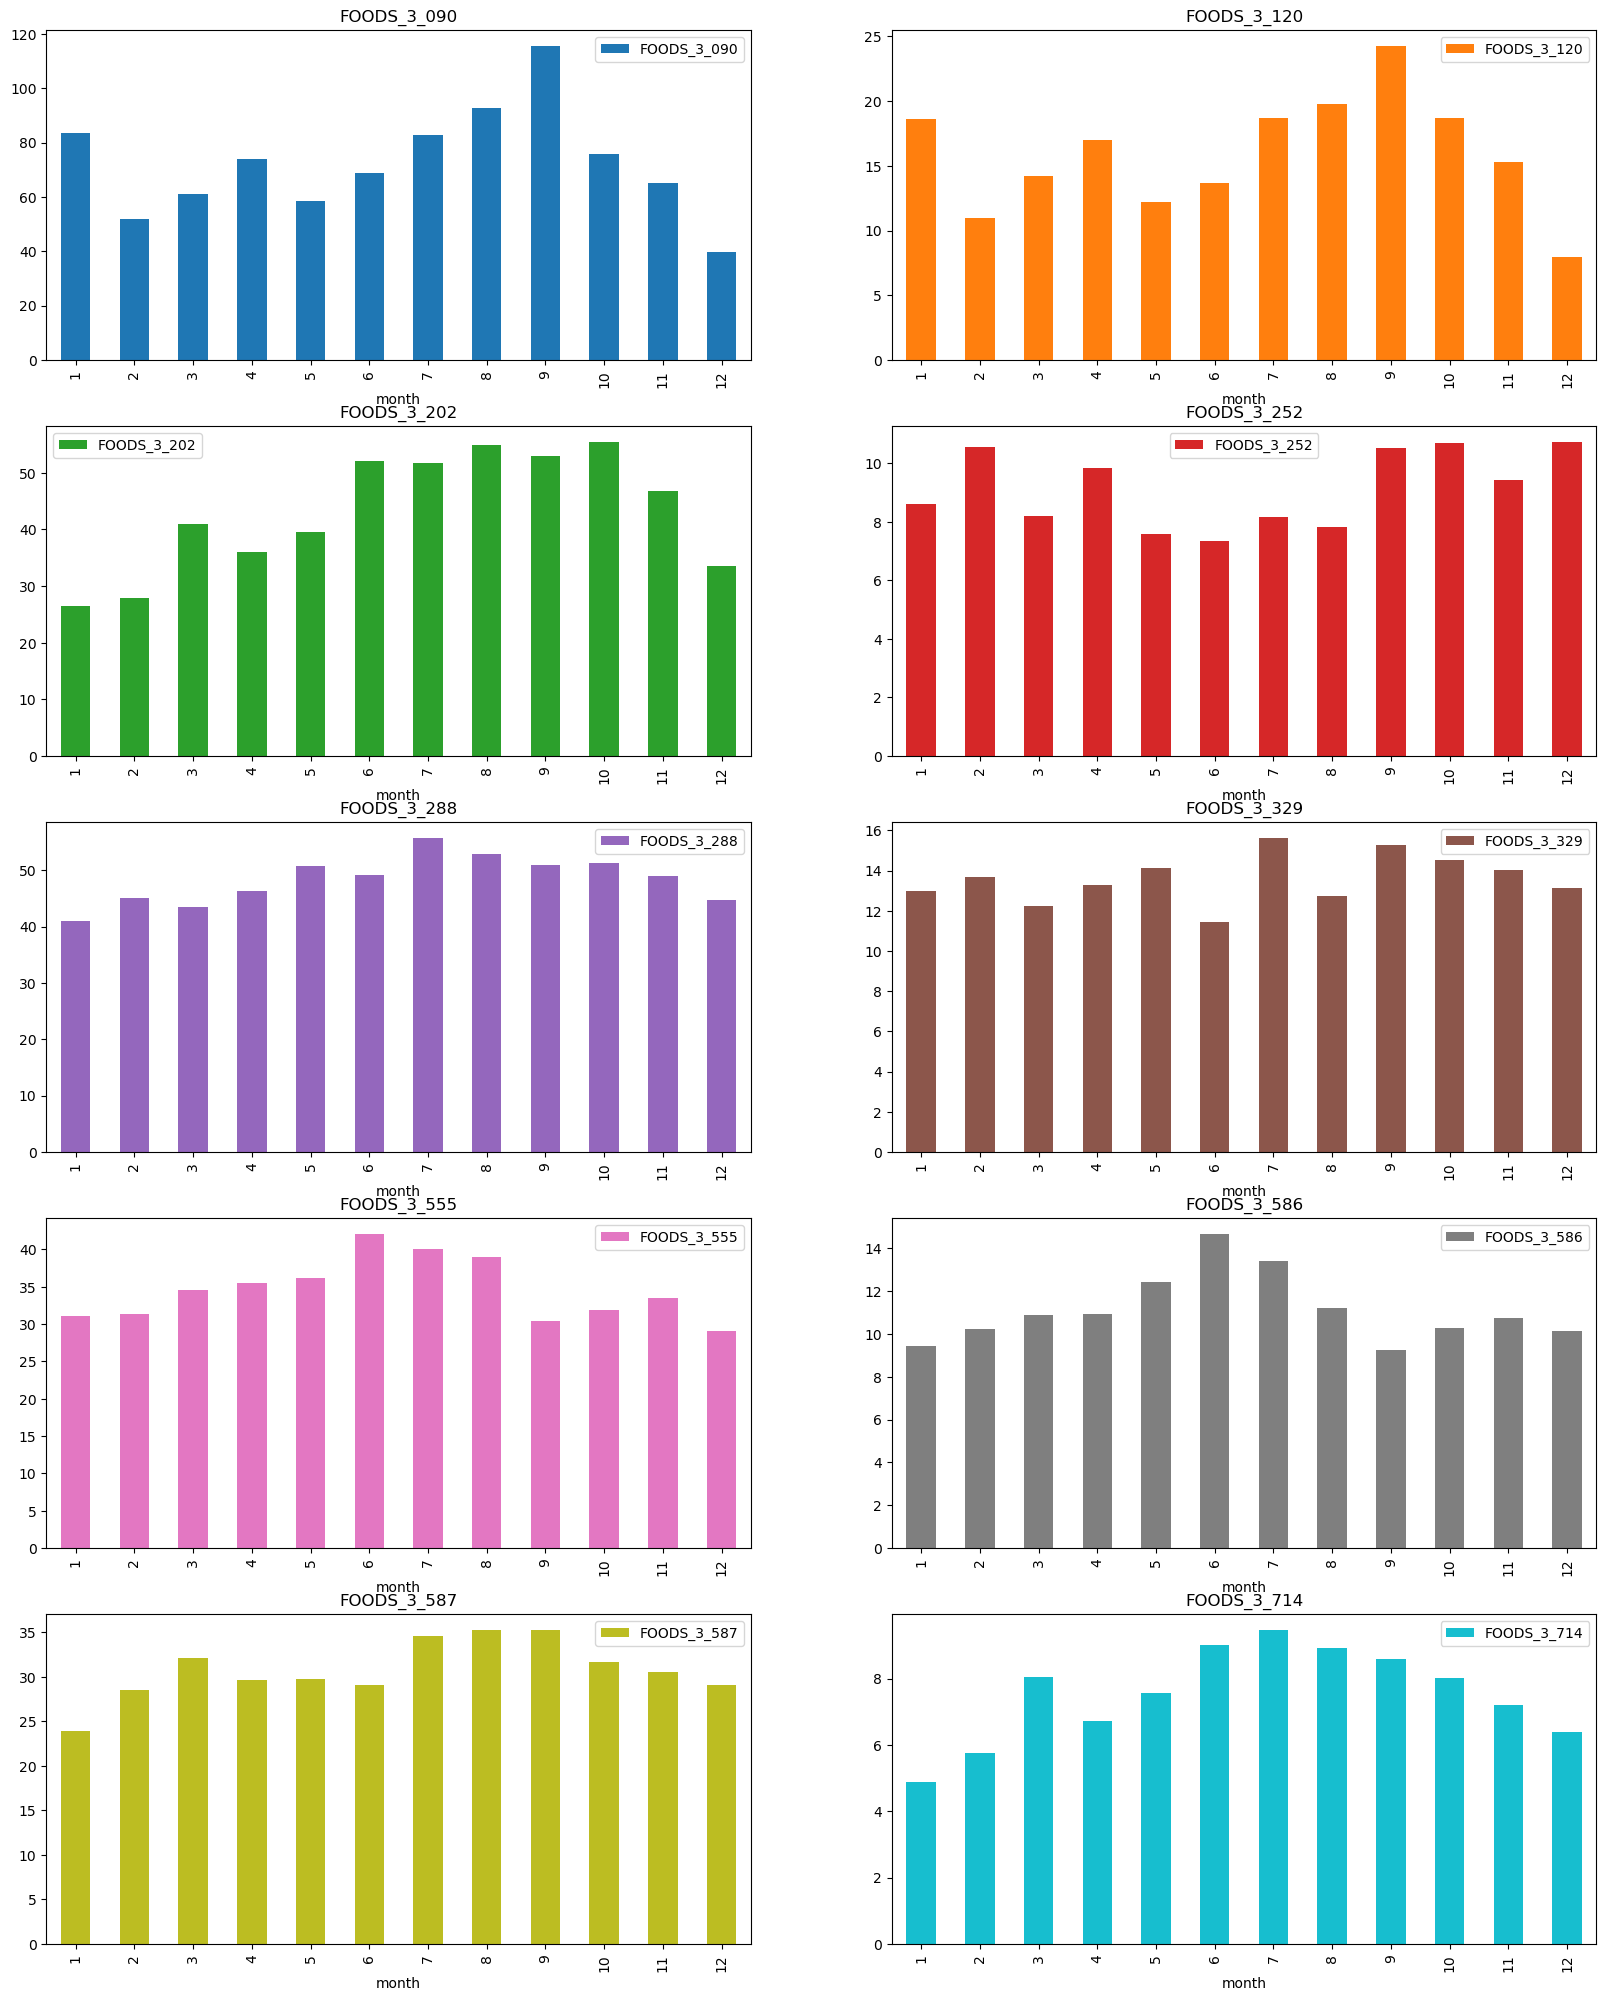

In [41]:
df.groupby(['month','item_id']).ventas.mean().unstack().plot.bar(subplots = True,  layout = (6,2), sharex=False, figsize=(20,30));

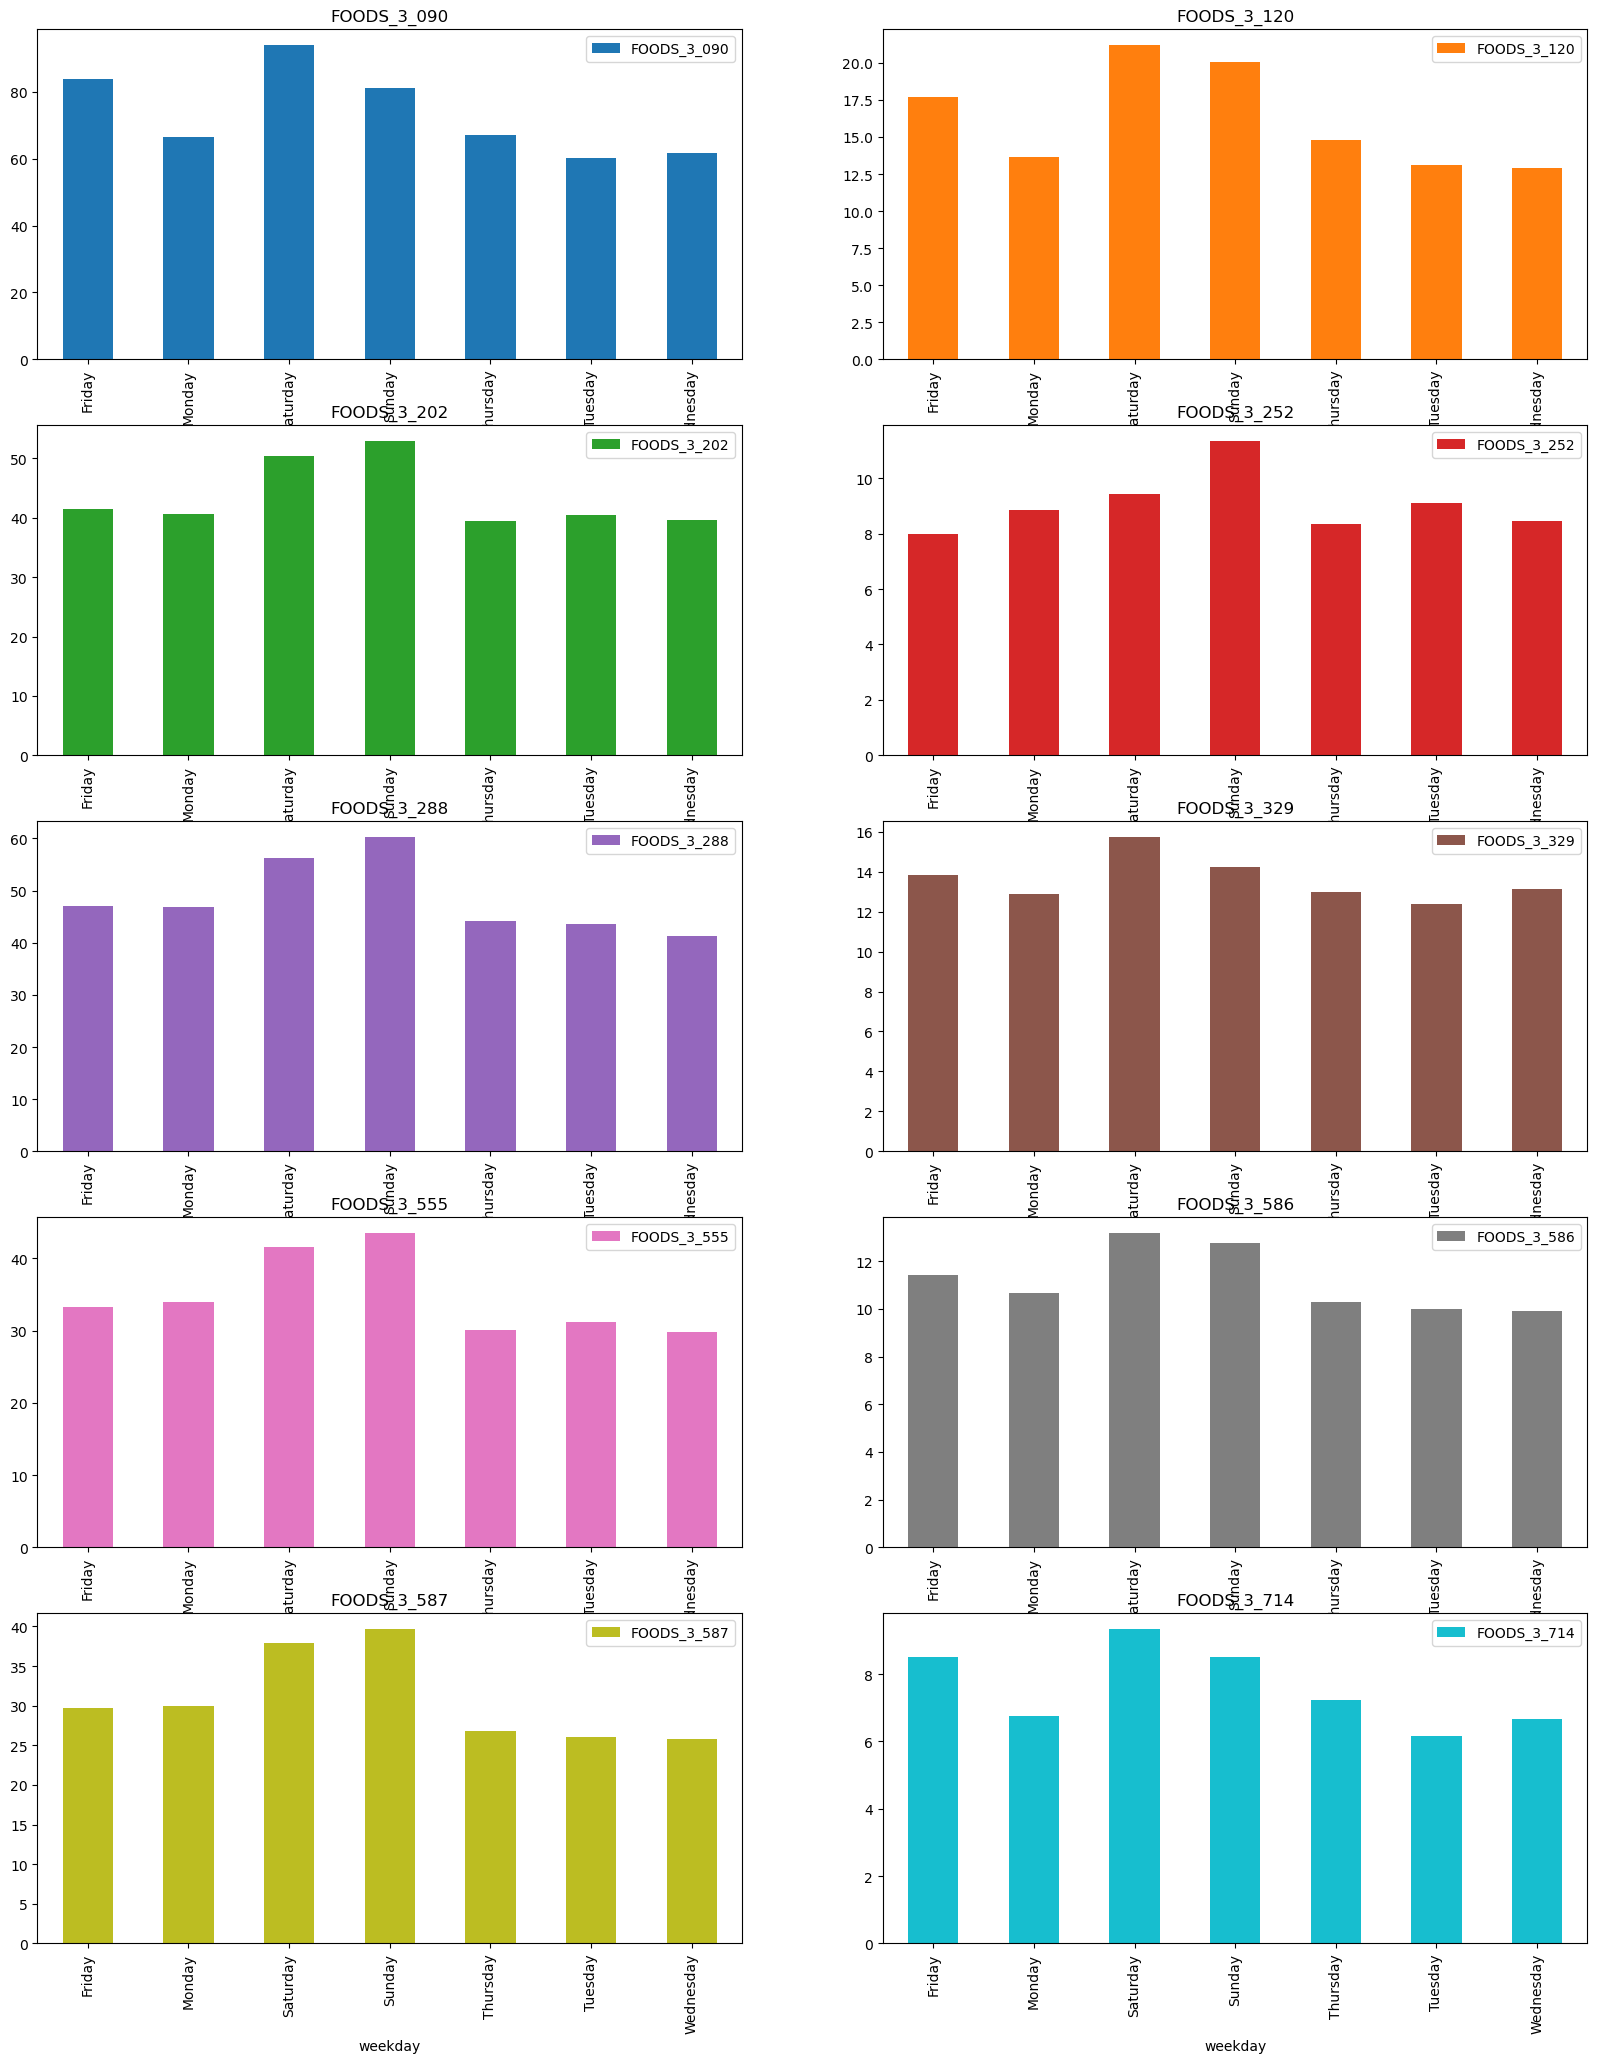

In [42]:
df.groupby(['weekday','item_id']).ventas.mean().unstack().plot.bar(subplots = True,  layout = (6,2), sharex=False, figsize=(20,30));

#### Estacionalidad por evento

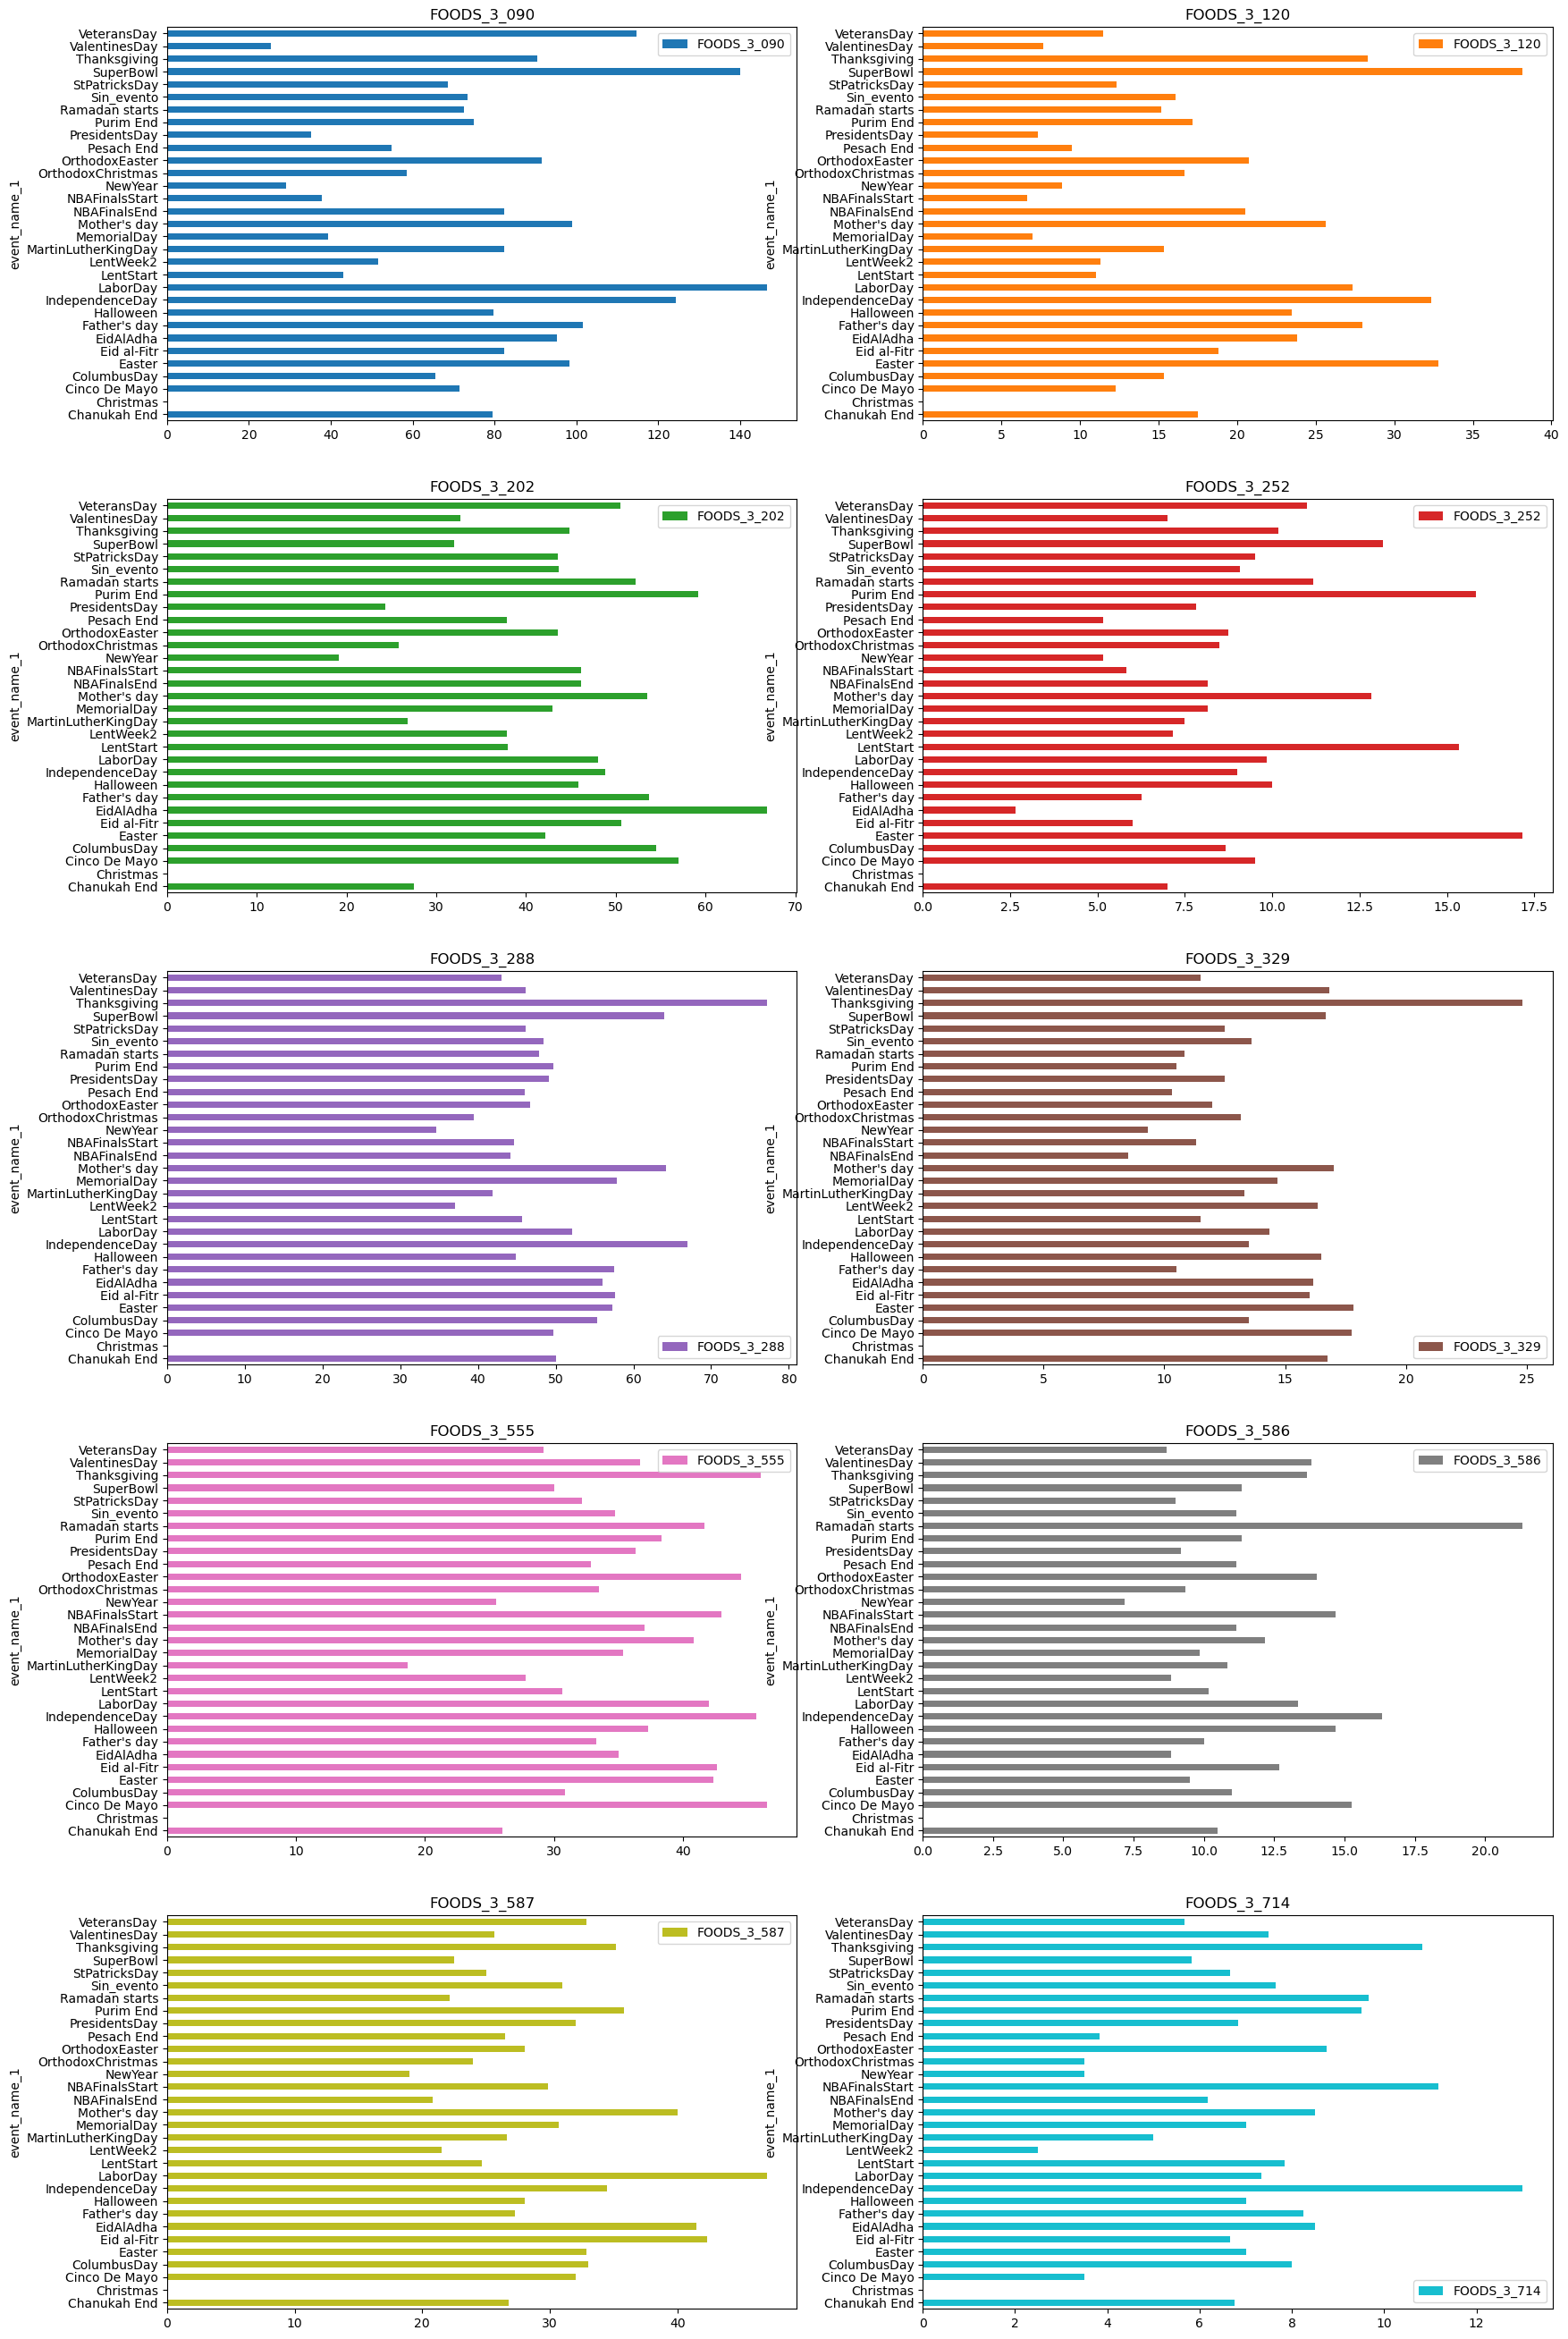

In [43]:
df.groupby(['event_name_1','item_id']).ventas.mean().unstack().plot.barh(subplots = True,  layout = (6,2), sharex=False, figsize=(20,40));

#### Estacionalidad por tipo de evento

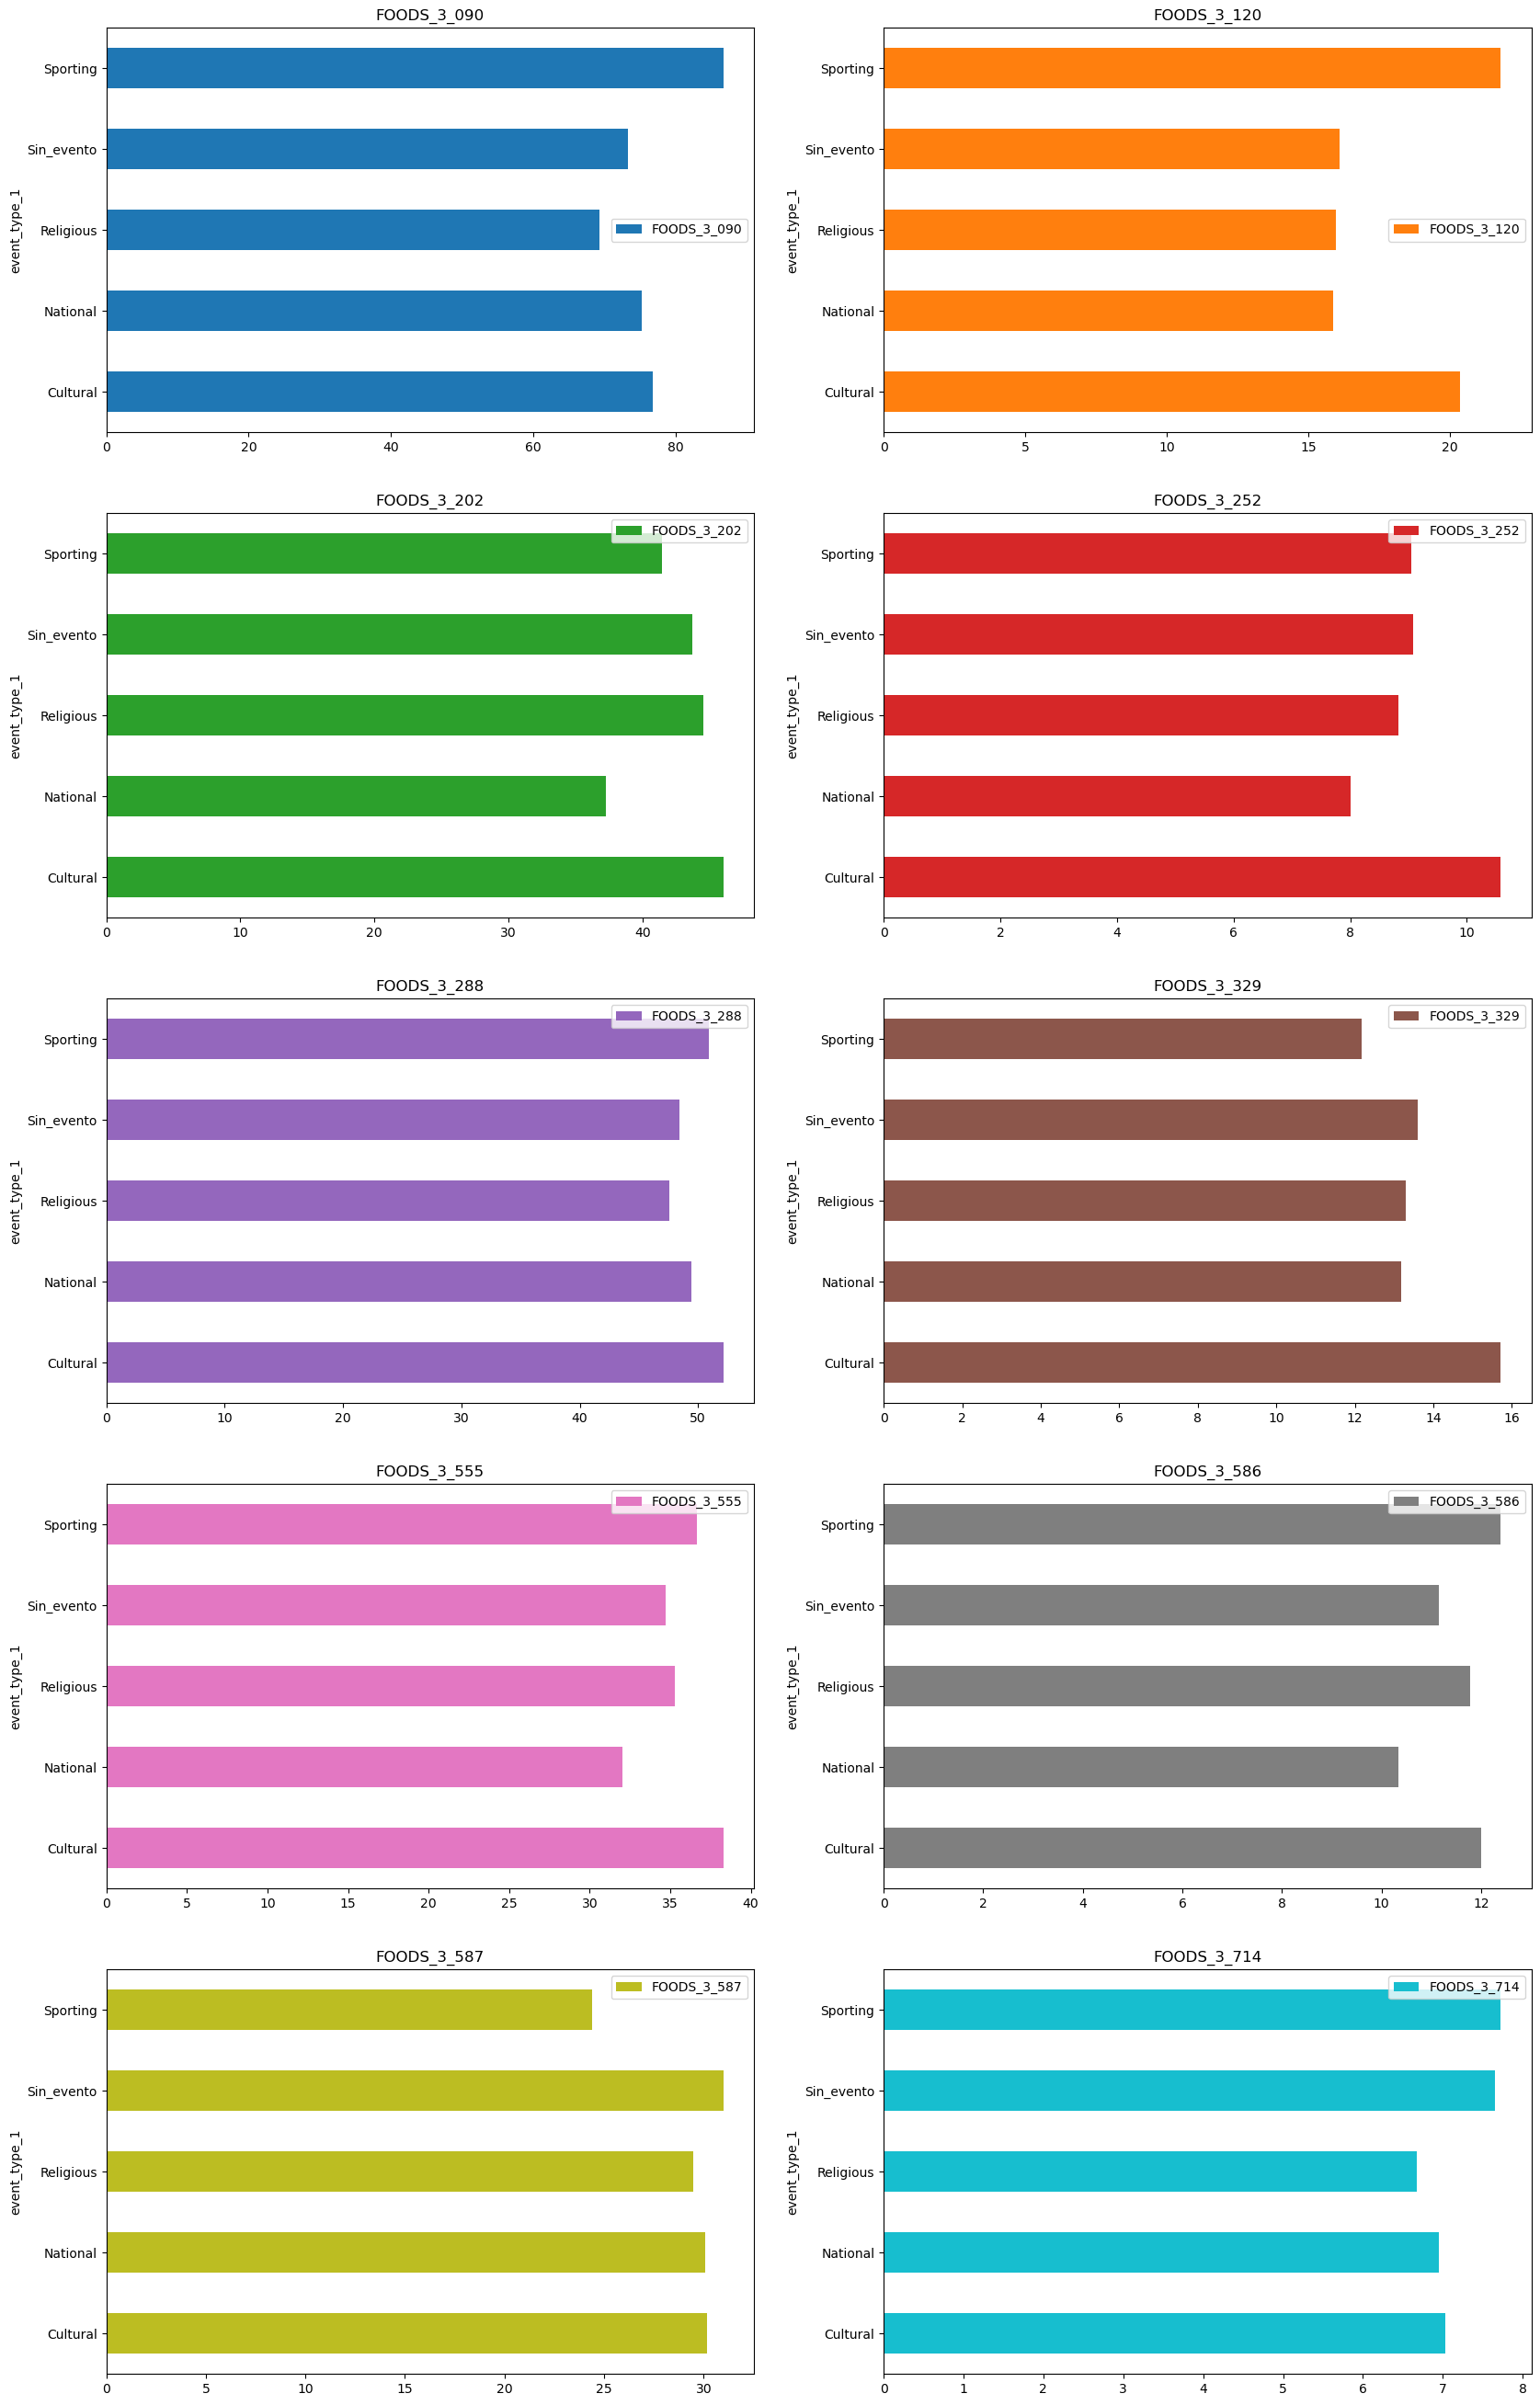

In [44]:
df.groupby(['event_type_1','item_id']).ventas.mean().unstack().plot.barh(subplots = True,  layout = (6,2), sharex=False, figsize=(20,40));

Conclusiones:

* Todas estas variables sí parecen afectar lo cual es buena noticia

## GUARDAR DATASETS TRAS EDA

In [45]:
cat.to_pickle("../02_datos/03_Entrenamiento/cat_resultado_eda.pkl")
num.to_pickle("../02_datos/03_Entrenamiento/num_resultado_eda.pkl")